<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/Breakout/Resistance_Breakout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Resistance Breakout Strategy & Performance Scanner

This notebook implements a technical analysis scanner designed to identify **Resistance Breakouts**. The strategy focuses on identifying stocks that establish a clear price ceiling and subsequently break through it with high momentum.

**Key Features:**
* **Dynamic Resistance Detection:** Identifies price levels where a ticker has 'touched' or peaked multiple times (configurable via `min_touches`) within a lookback window.
* **Breakout Validation:** Triggers a signal only when the price closes above the resistance level by a specified percentage buffer and sets a new local high.
* **Ticker Locking:** Prevents redundant signals by enforcing a 'cool-off' period (e.g., 10 days) after a breakout is detected for a specific ticker.
* **Forward Performance Tracking:** Automatically calculates the 1-day through 5-day returns following each breakout and tracks the 'Success Rate' (percentage of time the price remains above the breakout level).
* **Buffered Data Ingestion:** Automatically downloads an extra 10 days of historical data beyond the scan window to ensure end-of-year signals have complete performance data.

**Current Configuration:** Scanning high-volume tickers for breakouts between January 2025 and December 2025.

In [17]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates # Import matplotlib.dates


In [18]:
# Clear all DataFrames from memory
import gc

# Get a list of all variables in the global namespace
all_vars = list(globals().keys())

# Identify and delete pandas DataFrames
for var_name in all_vars:
    if isinstance(globals()[var_name], pd.DataFrame):
        del globals()[var_name]
        print(f"Deleted DataFrame: {var_name}")

# Run garbage collector to free up memory
gc.collect()

print("All DataFrames cleared from memory.")

Deleted DataFrame: csv_input
Deleted DataFrame: full_historical_data
Deleted DataFrame: watchlist_df
Deleted DataFrame: performance_df
Deleted DataFrame: valid_subset
Deleted DataFrame: df_lookup
Deleted DataFrame: weekly_triggers
All DataFrames cleared from memory.


In [19]:
# These are Google Drive file IDs. To get your own, right-click on the file in Google Drive, select 'Share', then 'Get link'. The ID is the part of the URL after 'id='.
OptionVolume_id = '1OGdLINK3zjlx6-lMq86SVq9TkbcglkeI'
OptionVolume = f'https://drive.google.com/uc?export=download&id={OptionVolume_id}'

OptionVolume200_id = '1gcwD510l4GFGNcKsbExR3GvKnDZwCHy4'
OptionVolume200 = f'https://drive.google.com/uc?export=download&id={OptionVolume200_id}'

### 1. Configuration and Data Ingestion
This cell defines the date range for the scan and calculates a 10-day 'buffer' for `DATA_END_DATE` to ensure we can track performance for year-end breakouts. It then loads the ticker list from Google Drive and downloads the necessary historical data via `yfinance`.

In [20]:
# 1. Parameterize scan range and download buffer
START_SCAN = '2024-01-01'
END_SCAN = '2025-12-31'  # The period evaluated for breakouts

# Calculate a data download end date exactly 10 days past the scan period
# to ensure full forward-performance data for year-end signals.
END_SCAN_DT = pd.to_datetime(END_SCAN)
DATA_END_DATE = (END_SCAN_DT + timedelta(days=10)).strftime('%Y-%m-%d')

print(f"Scan range: {START_SCAN} to {END_SCAN}")
print(f"Downloading data through: {DATA_END_DATE} (10-day performance buffer)")

# 2. Ingest list of tickers from your CSV file
tickers = []
try:
    csv_input = pd.read_csv(OptionVolume)
    tickers = csv_input['Symbol'].dropna().unique().tolist()
    tickers = [str(t).strip().upper() for t in tickers if str(t).isalpha()]
except Exception as e:
    print(f"Error reading CSV: {e}. Falling back to test list.")
    tickers = ["AAPL", "MSFT", "AMD", "NVDA", "INTC", "TSLA"]

# 3. Batch download historical data once using the buffered date
full_historical_data = pd.DataFrame()
if tickers:
    print(f"Downloading historical data for {len(tickers)} tickers...")
    try:
        full_historical_data = yf.download(tickers, start=START_SCAN, end=DATA_END_DATE, group_by='ticker', auto_adjust=True)
        print("Historical data download complete.")
    except Exception as e:
        print(f"Error fetching data: {e}")

if full_historical_data.empty:
    print("No historical data available for analysis.")

Scan range: 2024-01-01 to 2025-12-31


[*********************100%***********************]  99 of 99 completed

Historical data download complete.


### 2. Resistance Breakout Scanner
This function iterates through the historical data to find price levels where a stock has peaked multiple times. It triggers a signal when the price decisively closes above that resistance level. It also includes a 'cool-off' mechanism to prevent redundant signals for the same stock.

In [21]:
def scan_resistance_breakout(ticker_list, full_data,
                             start_date_str, end_date_str,
                             resistance_buffer_pct=0.005, min_touches=3,
                             lookback_window=60, breakout_buffer_pct=0.0025,
                             cool_off_days=30):
    """
    Scans for unique resistance breakouts between start_date_str and end_date_str.
    """
    candidates = []
    last_breakout_date = {}

    # Convert strings to datetime objects for comparison
    start_dt = pd.to_datetime(start_date_str)
    end_dt = pd.to_datetime(end_date_str)

    print(f"Scanning {len(ticker_list)} tickers for triggers between {start_date_str} and {end_dt.strftime('%Y-%m-%d')}...")

    for ticker in ticker_list:
        try:
            if ticker not in full_data.columns.levels[0]:
                continue
            df = full_data[ticker].dropna().copy()
            if df.empty or len(df) < lookback_window + 2:
                continue

            last_breakout_date[ticker] = None

            for i in range(lookback_window, len(df)):
                current_date = df.index[i]

                # Filter: Only identify triggers within the defined scan window
                if current_date < start_dt or current_date > end_dt:
                    continue

                # Check if we are within the cool-off period
                if last_breakout_date[ticker] is not None:
                    days_since = (current_date - last_breakout_date[ticker]).days
                    if days_since < cool_off_days:
                        continue

                recent_df = df.iloc[i-lookback_window : i]
                current_close = df['Close'].iloc[i]
                previous_close = df['Close'].iloc[i-1]
                highest_high_in_window = recent_df['High'].max()

                # 1. Identify Resistance Levels
                highs = recent_df['High'].values
                sorted_highs = np.sort(highs)
                identified_levels = []

                for val in sorted_highs:
                    cluster = [h for h in highs if abs(h - val) / val <= resistance_buffer_pct]
                    if len(cluster) >= min_touches:
                        res_level = np.mean(cluster)
                        if not any(abs(res_level - lvl) / lvl < 0.02 for lvl, _ in identified_levels):
                            identified_levels.append((res_level, len(cluster)))

                # 2. Check Breakout Conditions
                for res_price, touches in identified_levels:
                    breakout_threshold = res_price * (1 + breakout_buffer_pct)

                    # Combined condition: Close above resistance AND new high for the lookback window
                    if (current_close > breakout_threshold) and \
                       (previous_close <= breakout_threshold) and \
                       (current_close > highest_high_in_window):
                            candidates.append({
                                "Ticker": ticker,
                                "Date": current_date.strftime('%Y-%m-%d'),
                                "Res_Level": round(res_price, 2),
                                "Breakout_Threshold": round(breakout_threshold, 2),
                                "Touches": touches,
                                "Close": round(current_close, 2),
                                "Prev_High": round(highest_high_in_window, 2)
                            })
                            last_breakout_date[ticker] = current_date
                            break

        except Exception:
            continue

    return pd.DataFrame(candidates)

# Re-run the scan using the parameter window
if 'full_historical_data' in globals() and not full_historical_data.empty:
    watchlist_df = scan_resistance_breakout(
        tickers,
        full_historical_data,
        start_date_str=START_SCAN,
        end_date_str=END_SCAN,
        min_touches=5,
        cool_off_days=5
    )
    print(f"\nTotal triggers identified: {len(watchlist_df)}")
    display(watchlist_df.head(20))

Scanning 99 tickers for triggers between 2024-01-01 and 2025-12-31...

Total triggers identified: 323


,Ticker,Date,Res_Level,Breakout_Threshold,Touches,Close,Prev_High
0,SPY,2024-06-05,515.45,516.74,6,521.97,520.40
1,SPY,2024-09-19,548.63,550.00,12,559.21,556.97
2,SPY,2024-09-26,560.12,561.52,6,562.22,561.82
3,SPY,2024-11-06,572.28,573.71,9,580.63,575.80
4,SPY,2024-11-29,586.86,588.33,6,591.94,590.74
5,SPY,2025-06-24,594.85,596.33,10,601.68,598.20
6,SPY,2025-08-28,640.65,642.25,7,643.46,641.93
7,SPY,2025-09-18,654.84,656.48,5,656.69,656.21
8,SPY,2025-10-24,668.20,669.87,14,673.42,670.13
9,TSLA,2025-09-11,356.28,357.17,5,368.81,358.44


### 3. Performance Analysis and Validation
This final section calculates the forward returns for 1 to 5 days following every identified breakout. It generates a summary table showing the average returns and a 'Success Rate,' verifying how often the price stayed above the breakout level.

In [22]:
def calculate_post_breakout_performance(watchlist, full_data):
    results = []

    for _, row in watchlist.iterrows():
        ticker = row['Ticker']
        breakout_date = row['Date']
        res_level = row['Res_Level']
        breakout_close = row['Close']

        if ticker not in full_data.columns.levels[0]:
            continue

        df = full_data[ticker].dropna()
        try:
            idx = df.index.get_loc(breakout_date)
        except KeyError:
            continue

        performance = row.to_dict()

        # Loop specifically for Days 1 through 5
        for d in [1, 2, 3, 4, 5]:
            future_idx = idx + d
            if future_idx < len(df):
                future_close = df['Close'].iloc[future_idx]
                ret = ((future_close - breakout_close) / breakout_close) * 100
                performance[f'Day_{d}_Return_%'] = round(ret, 2)
                performance[f'Day_{d}_Above_Res'] = bool(future_close >= res_level)
            else:
                performance[f'Day_{d}_Return_%'] = np.nan
                performance[f'Day_{d}_Above_Res'] = None

        results.append(performance)

    return pd.DataFrame(results)

if 'watchlist_df' in globals() and not watchlist_df.empty:
    performance_df = calculate_post_breakout_performance(watchlist_df, full_historical_data)

    # Calculate Summary for Days 1-5
    summary_data = {}
    validation_log = []

    for d in [1, 2, 3, 4, 5]:
        col_name = f'Day_{d}_Above_Res'
        valid_subset = performance_df[performance_df[col_name].notnull()]

        total_valid = len(valid_subset)
        success_count = valid_subset[col_name].sum() if total_valid > 0 else 0
        fail_count = total_valid - success_count

        avg_ret = valid_subset[f'Day_{d}_Return_%'].mean() if total_valid > 0 else np.nan
        pct_above = (success_count / total_valid * 100) if total_valid > 0 else 0

        summary_data[f'Day_{d} Avg Return %'] = avg_ret
        summary_data[f'Day_{d} % Above Res'] = pct_above

        validation_log.append({"Day": d, "Total": total_valid, "Above": success_count, "Below": fail_count})

    print("--- Updated Performance Summary (with 10-day buffer) ---")
    display(pd.Series(summary_data).to_frame(name='Value'))

    print("\n--- Raw Verification Counts ---")
    display(pd.DataFrame(validation_log))

    print("\n--- Detailed Performance Table (Full) ---")
    # Using pd.option_context to ensure the full table is visible if desired,
    # or simply display() for the standard scrollable interactive table.
    display(performance_df)

--- Updated Performance Summary (with 10-day buffer) ---


,Value
Day_1 Avg Return %,0.144861
Day_1 % Above Res,91.950464
Day_2 Avg Return %,0.321920
Day_2 % Above Res,89.164087
Day_3 Avg Return %,0.623189
Day_3 % Above Res,84.210526
Day_4 Avg Return %,0.579598
Day_4 % Above Res,81.424149
Day_5 Avg Return %,0.825511
Day_5 % Above Res,78.637771



--- Raw Verification Counts ---


,Day,Total,Above,Below
0,1,323,297,26
1,2,323,288,35
2,3,323,272,51
3,4,323,263,60
4,5,323,254,69



--- Detailed Performance Table (Full) ---


,Ticker,Date,Res_Level,Breakout_Threshold,Touches,Close,Prev_High,Day_1_Return_%,Day_1_Above_Res,Day_2_Return_%,Day_2_Above_Res,Day_3_Return_%,Day_3_Above_Res,Day_4_Return_%,Day_4_Above_Res,Day_5_Return_%,Day_5_Above_Res
0,SPY,2024-06-05,515.45,516.74,6,521.97,520.40,-0.00,True,-0.12,True,0.18,True,0.43,True,1.25,True
1,SPY,2024-09-19,548.63,550.00,12,559.21,556.97,-0.17,True,0.08,True,0.36,True,0.14,True,0.54,True
2,SPY,2024-09-26,560.12,561.52,6,562.22,561.82,-0.14,True,0.26,True,-0.64,False,-0.60,False,-0.78,False
3,SPY,2024-11-06,572.28,573.71,9,580.63,575.80,0.77,True,1.21,True,1.31,True,0.99,True,1.04,True
4,SPY,2024-11-29,586.86,588.33,6,591.94,590.74,0.18,True,0.23,True,0.85,True,0.68,True,0.87,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318,FCX,2024-09-26,50.58,50.71,5,50.74,50.65,-1.11,False,-3.84,False,-2.96,False,-2.11,False,-4.13,False
319,FCX,2025-03-24,39.77,39.87,7,40.95,40.87,3.36,True,-0.29,True,-3.92,False,-7.67,False,-9.01,False
320,INTU,2025-05-23,665.89,667.55,5,714.32,669.55,4.42,True,4.77,True,5.15,True,4.63,True,6.23,True
321,INTU,2025-07-28,780.91,782.86,7,793.36,785.18,0.95,True,1.08,True,-1.70,False,-2.83,False,-1.74,False


### 4. Weekly Trigger Analysis

Let's visualize the number of resistance breakout triggers identified each week. This can help in understanding the temporal distribution of these events.

Generating charts for 323 total triggers (Sunday Start)...


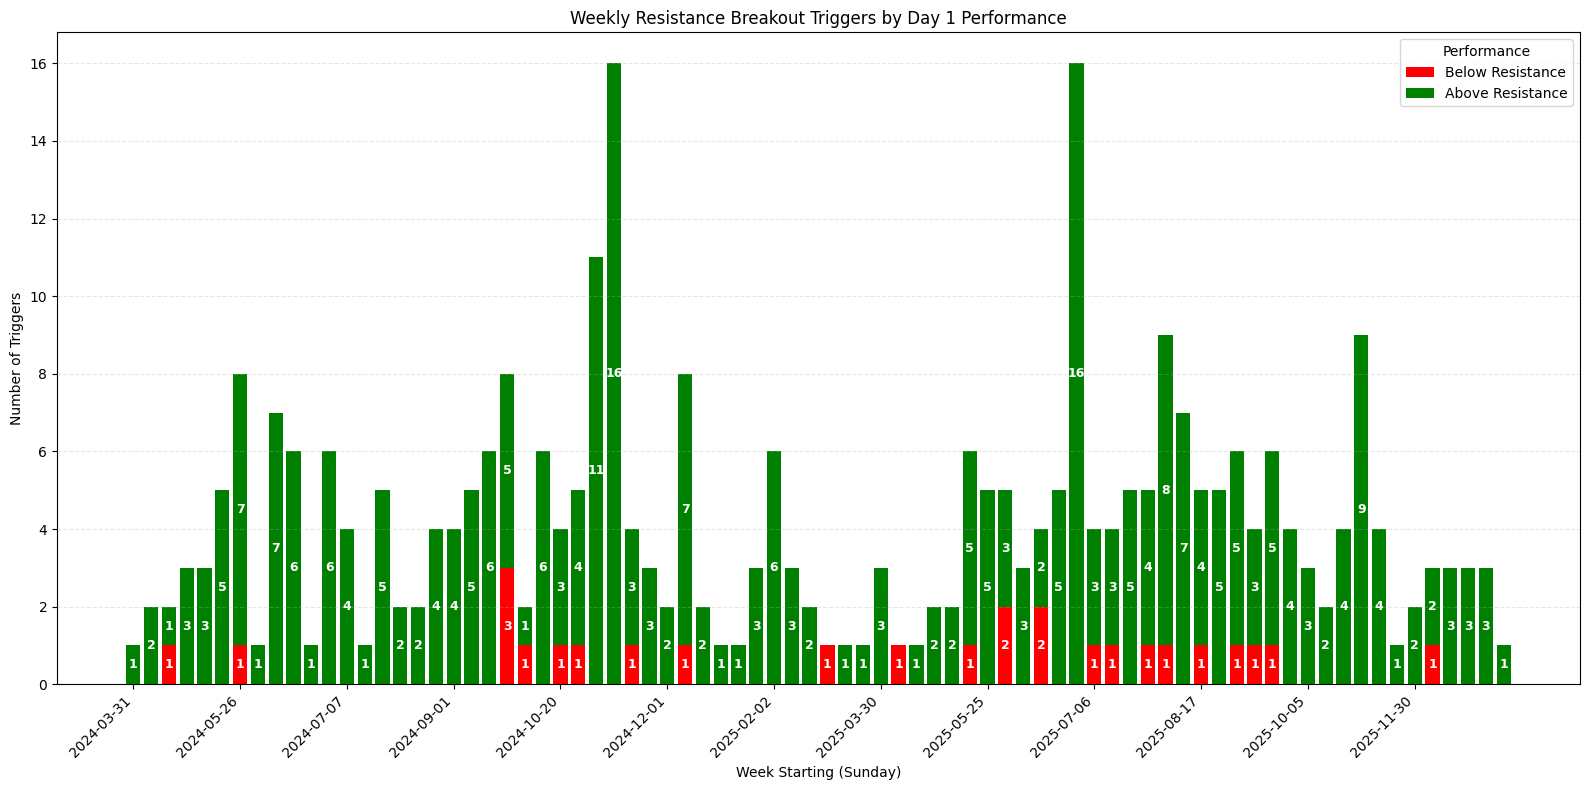

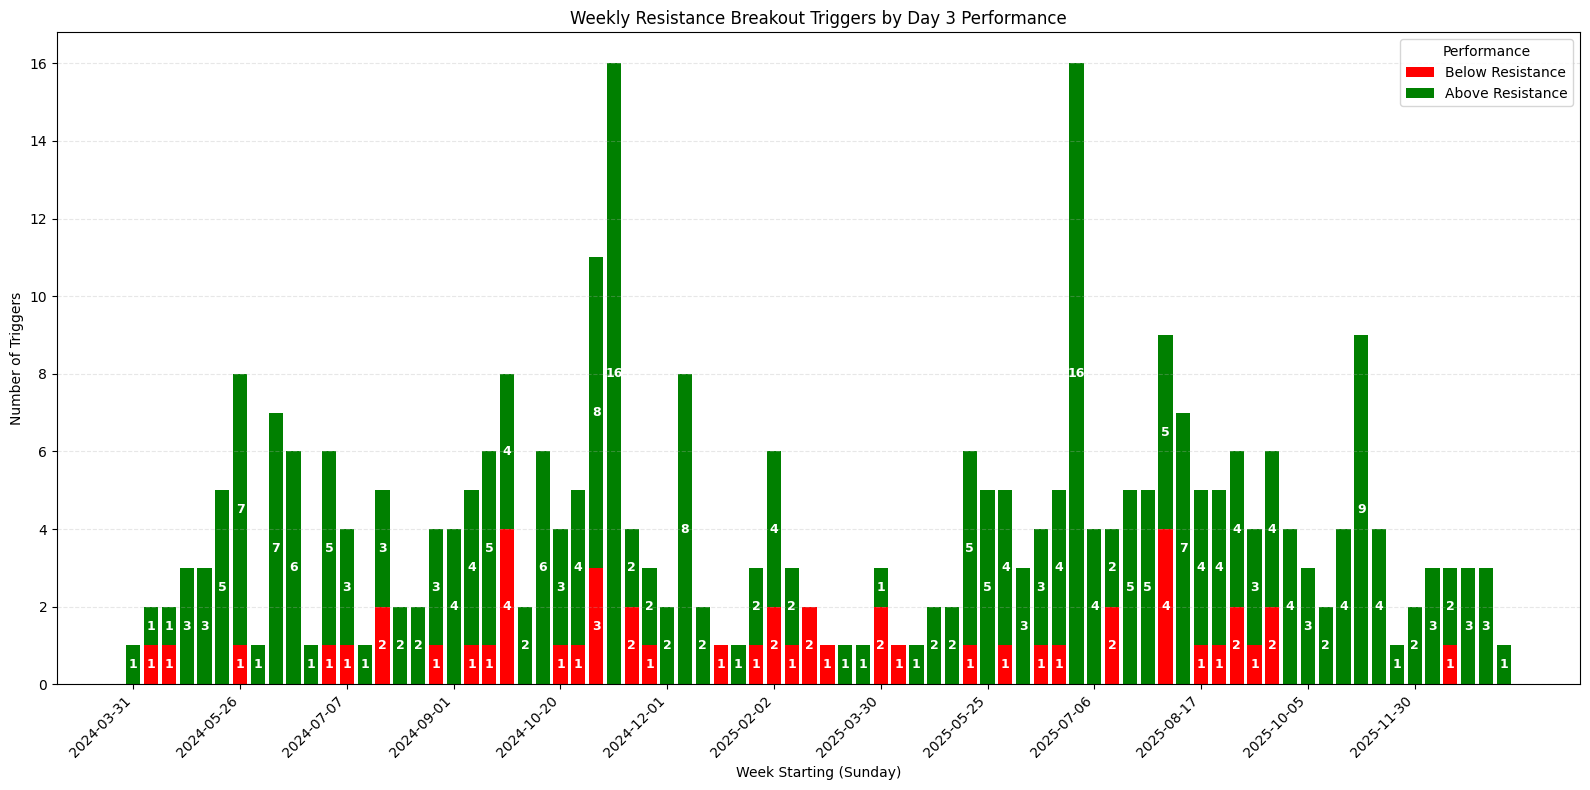

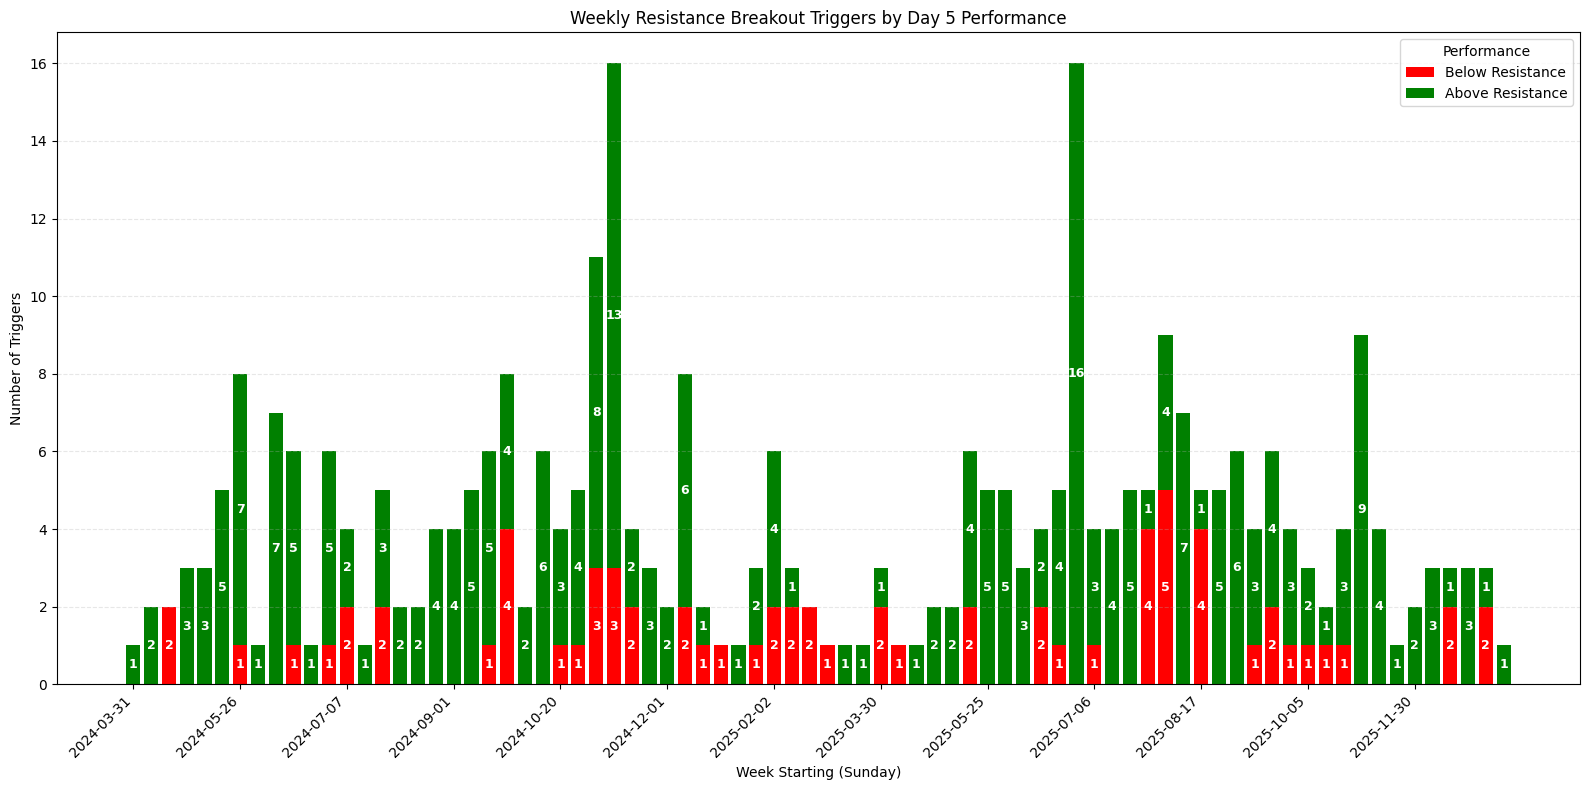

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_stacked_performance(df, day_column, title_suffix):
    if 'performance_df' in globals() and not performance_df.empty:
        # 1. Prepare Data
        df_plot = df.copy()
        df_plot['Date'] = pd.to_datetime(df_plot['Date'])

        # Group by Sunday-aligned week ('W-SUN') and sort
        weekly_data = df_plot.groupby([pd.Grouper(key='Date', freq='W-SUN'), day_column])['Ticker'].count().unstack(fill_value=0)
        weekly_data = weekly_data.sort_index()

        # Map labels and ensure order (Red on bottom, Green on top)
        weekly_data = weekly_data.rename(columns={True: 'Above Resistance', False: 'Below Resistance'})

        # Extract data for plotting
        dates = [d.strftime('%Y-%m-%d') for d in weekly_data.index]
        below = weekly_data['Below Resistance'].values if 'Below Resistance' in weekly_data.columns else np.zeros(len(weekly_data))
        above = weekly_data['Above Resistance'].values if 'Above Resistance' in weekly_data.columns else np.zeros(len(weekly_data))

        # 2. Plotting
        fig, ax = plt.subplots(figsize=(16, 8))

        # Plot bars
        ax.bar(dates, below, color='red', label='Below Resistance', width=0.8)
        ax.bar(dates, above, bottom=below, color='green', label='Above Resistance', width=0.8)

        # 3. Formatting
        plt.title(f'Weekly Resistance Breakout Triggers by {title_suffix} Performance')
        plt.xlabel('Week Starting (Sunday)')
        plt.ylabel('Number of Triggers')

        # X-Axis Ticks: Show every Nth label to prevent overlapping
        n = max(1, len(dates) // 12)
        ax.set_xticks(range(0, len(dates), n))
        ax.set_xticklabels(dates[::n], rotation=45, ha='right')

        plt.grid(axis='y', linestyle='--', alpha=0.3)
        plt.legend(title='Performance')

        # 4. Data Labels in White
        for container in ax.containers:
            ax.bar_label(container, label_type='center', color='white', fontweight='bold', fontsize=9,
                         fmt=lambda x: f'{int(x)}' if x > 0 else '')

        plt.tight_layout()
        plt.show()
    else:
        print("performance_df is empty or not found.")

# Run for the specific days requested
if 'performance_df' in globals() and not performance_df.empty:
    print(f"Generating charts for {len(performance_df)} total triggers (Sunday Start)...")
    for day_num, label in [(1, 'Day 1'), (3, 'Day 3'), (5, 'Day 5')]:
        plot_stacked_performance(performance_df, f'Day_{day_num}_Above_Res', label)
else:
    print("performance_df not found.")